<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Bin_Budget_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import json
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42

In [ ]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

RESULTS = {}   # everything worth reporting gets dumped in here
OUTDIR = "results"
os.makedirs(OUTDIR, exist_ok=True)

device: cuda


### downloading + pairing the dataset

In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle && cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d soumikrakshit/nyu-depth-v2 -q

Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2
License(s): unknown


In [ ]:
BASE_PATH = "nyu_data/nyu_data/data/nyu2_train"

In [ ]:
import os, glob, zipfile

# --- unzip (this was the missing step) ---
if not os.path.exists("nyu_data"):
    with zipfile.ZipFile("nyu-depth-v2.zip", "r") as z:
        z.extractall("nyu_data")
    print("extracted")
else:
    print("nyu_data already exists, skipping extract")

# --- verify where the train folder actually landed ---
candidates = glob.glob("nyu_data/**/nyu2_train", recursive=True)
print("nyu2_train candidates:", candidates)

assert candidates, "nyu2_train not found — check the extracted folder layout above"
BASE_PATH = candidates[0]
print("BASE_PATH =", BASE_PATH)


def build_pairs(base_path):
    rgb_files, depth_files = [], []
    for folder in sorted(glob.glob(os.path.join(base_path, "*"))):
        for jpg in sorted(glob.glob(os.path.join(folder, "*.jpg"))):
            png = os.path.splitext(jpg)[0] + ".png"
            if os.path.exists(png):
                rgb_files.append(jpg)
                depth_files.append(png)
    return rgb_files, depth_files

rgb_files, depth_files = build_pairs(BASE_PATH)
print("total pairs found:", len(rgb_files))
assert len(rgb_files) > 0, "no pairs found — inspect BASE_PATH contents"

RESULTS["total_pairs"] = len(rgb_files)
RESULTS["base_path"] = BASE_PATH

extracted
nyu2_train candidates: ['nyu_data/nyu_data/data/nyu2_train']
BASE_PATH = nyu_data/nyu_data/data/nyu2_train
total pairs found: 50688


### adaptive (quantile) depth binning + scoring

In [ ]:
BIN_CHOICES = [32, 64, 128, 256]
MAX_BINS = 256

def quantize_uniform(depth, bins):
    """Uniform bins across [min, max] — the OLD behaviour, kept as a baseline."""
    depth = depth.astype(np.float32)
    edges = np.linspace(depth.min(), depth.max(), bins)
    idx = np.clip(np.digitize(depth, edges) - 1, 0, bins - 1)
    return edges[idx]

def quantize_adaptive(depth, bins):
    """Quantile bins on a continuous depth scale (avoids uint8 edge collapse)."""
    d = depth.astype(np.float64)
    # dither by half a quantisation step to break uint8 ties
    rng = np.random.default_rng(0)
    flat = d.ravel() + rng.uniform(-0.5, 0.5, d.size)

    qs = np.linspace(0.0, 100.0, bins + 1)
    edges = np.percentile(flat, qs, method="linear")
    edges = np.maximum.accumulate(edges)                 # enforce monotone
    # nudge any exact ties apart instead of dropping them
    tiny = 1e-9 * max(float(np.ptp(flat)), 1.0)
    for i in range(1, edges.size):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + tiny

    idx = np.clip(np.digitize(flat, edges[1:-1]), 0, bins - 1)
    sums = np.bincount(idx, weights=flat, minlength=bins)
    cnts = np.bincount(idx, minlength=bins)
    mids = 0.5 * (edges[:-1] + edges[1:])
    centers = np.where(cnts > 0, sums / np.maximum(cnts, 1), mids)
    return centers[idx].reshape(d.shape).astype(np.float32)

# the pipeline uses adaptive binning from here on
def quantize_depth(depth, bins):
    return quantize_adaptive(depth, bins)

def mse(a, b):
    return float(np.mean((a.astype(np.float32) - b.astype(np.float32)) ** 2))

In [ ]:
_probe = np.array(Image.open(depth_files[0]))
print("effective bins @256:", np.unique(quantize_adaptive(_probe, 256)).size)

effective bins @256: 256


So `E(x, b)` is a *quantization* error that says how much detail is lost when the depth map is represented with b bins and hence not a full depth-estimation error. That is still a valid proxy for how much bin resolution a scene actually needs

### lambda sweep on a fixed random sample

In [ ]:
seed_everything()
SUBSET_SIZE = 1000

subset_idx   = random.sample(range(len(rgb_files)), SUBSET_SIZE)
subset_rgb   = [rgb_files[i]   for i in subset_idx]
subset_depth = [depth_files[i] for i in subset_idx]

# quantization errors are independent of lambda -> compute once, reuse forever
print("computing quantization errors (one pass)...")
error_cache = []
for k, p in enumerate(subset_depth):
    d = np.array(Image.open(p))
    error_cache.append([mse(d, quantize_depth(d, b)) for b in BIN_CHOICES])
    if (k + 1) % 100 == 0:
        print(f"  {k+1}/{SUBSET_SIZE}")
error_cache = np.array(error_cache)              # (N, 4)
costs = np.array([b / MAX_BINS for b in BIN_CHOICES])   # (4,)

def labels_for_lambda(lam):
    return np.argmin(error_cache + lam * costs, axis=1)

lam_table = {}
for lam in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    counts = Counter(BIN_CHOICES[i] for i in labels_for_lambda(lam))
    total3 = sum(counts[b] for b in [64, 128, 256])          # excl. pruned 32
    lam_table[lam] = {
        "counts": {b: counts[b] for b in BIN_CHOICES},
        "pct_3class": {b: round(100 * counts[b] / total3, 1) for b in [64, 128, 256]},
    }
    print(f"lambda={lam:<4} -> " +
          "  ".join(f"{b}:{counts[b]:>4}" for b in BIN_CHOICES) +
          "   | 3-class %: " +
          "  ".join(f"{b}:{lam_table[lam]['pct_3class'][b]:>5.1f}" for b in [64, 128, 256]))

RESULTS["lambda_sweep"] = lam_table
RESULTS["subset_size"] = SUBSET_SIZE

computing quantization errors (one pass)...
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000
lambda=0.1  -> 32:   2  64:  36  128: 317  256: 645   | 3-class %: 64:  3.6  128: 31.8  256: 64.6
lambda=0.2  -> 32:   6  64:  84  128: 441  256: 469   | 3-class %: 64:  8.5  128: 44.4  256: 47.2
lambda=0.3  -> 32:   8  64: 140  128: 456  256: 396   | 3-class %: 64: 14.1  128: 46.0  256: 39.9
lambda=0.4  -> 32:  13  64: 205  128: 440  256: 342   | 3-class %: 64: 20.8  128: 44.6  256: 34.7
lambda=0.5  -> 32:  22  64: 255  128: 422  256: 301   | 3-class %: 64: 26.1  128: 43.1  256: 30.8
lambda=0.6  -> 32:  26  64: 293  128: 417  256: 264   | 3-class %: 64: 30.1  128: 42.8  256: 27.1
lambda=0.7  -> 32:  39  64: 304  128: 429  256: 228   | 3-class %: 64: 31.6  128: 44.6  256: 23.7
lambda=0.8  -> 32:  43  64: 338  128: 418  256: 201   | 3-class %: 64: 35.3  128: 43.7  256: 21.0
lambda=1.0  -> 32:  50  64: 390  128: 429  256: 131   | 3-cla

In [ ]:
# --- sanity check: does adaptive binning actually break the 1/b^2 law? ---
seed_everything()
probe = [np.array(Image.open(depth_files[i]))
         for i in random.sample(range(len(depth_files)), 30)]

print(f"{'bins':>5} | {'uniform':>10} | {'adaptive':>10} | {'ratio':>6}")
prev_u = prev_a = None
for b in BIN_CHOICES:
    u = np.mean([mse(d, quantize_uniform(d, b)) for d in probe])
    a = np.mean([mse(d, quantize_adaptive(d, b)) for d in probe])
    ru = f"{prev_u/u:.2f}x" if prev_u else "  -"
    ra = f"{prev_a/a:.2f}x" if prev_a else "  -"
    print(f"{b:5d} | {u:10.5f} | {a:10.5f} |  u:{ru} a:{ra}")
    prev_u, prev_a = u, a

# per-image spread: how much do images DIFFER in what they need?
ratios = []
for d in probe:
    e64  = mse(d, quantize_adaptive(d, 64))
    e256 = mse(d, quantize_adaptive(d, 256))
    ratios.append(e64 / max(e256, 1e-9))
print(f"\nper-image e64/e256 ratio — adaptive: "
      f"min={np.min(ratios):.1f}  median={np.median(ratios):.1f}  max={np.max(ratios):.1f}")

ratios_u = []
for d in probe:
    e64  = mse(d, quantize_uniform(d, 64))
    e256 = mse(d, quantize_uniform(d, 256))
    ratios_u.append(e64 / max(e256, 1e-9))
print(f"per-image e64/e256 ratio — uniform:  "
      f"min={np.min(ratios_u):.1f}  median={np.median(ratios_u):.1f}  max={np.max(ratios_u):.1f}")

 bins |    uniform |   adaptive |  ratio
   32 |    6.37947 |    5.38178 |  u:  - a:  -
   64 |    1.59308 |    1.60843 |  u:4.00x a:3.35x
  128 |    0.39342 |    0.57693 |  u:4.05x a:2.79x
  256 |    0.09386 |    0.19960 |  u:4.19x a:2.89x

per-image e64/e256 ratio — adaptive: min=1.2  median=4.3  max=14.2
per-image e64/e256 ratio — uniform:  min=11.4  median=16.5  max=24.7


### labelling

In [ ]:
LAMBDA = 0.5
raw_labels = labels_for_lambda(LAMBDA).tolist()
print("raw label counts:", {BIN_CHOICES[k]: v for k, v in sorted(Counter(raw_labels).items())})
RESULTS["chosen_lambda"] = LAMBDA
RESULTS["raw_label_counts"] = {str(BIN_CHOICES[k]): v for k, v in sorted(Counter(raw_labels).items())}

raw label counts: {32: 22, 64: 255, 128: 422, 256: 301}


Alright, se we can see that the 32 bin class is coming very low, so I m jsut gonna drop it and will keep the remaining 3 classes.

### prune the 32-bin class, remap to 3 classes

In [ ]:
CLASS_TO_BINS = {0: 64, 1: 128, 2: 256}

kept_rgb, kept_depth, kept_labels = [], [], []
for r, d, l in zip(subset_rgb, subset_depth, raw_labels):
    if l == 0:            # 32-bin class -> dropped
        continue
    kept_rgb.append(r)
    kept_depth.append(d)
    kept_labels.append(l - 1)

print("kept samples:", len(kept_rgb))
print("class counts:", {CLASS_TO_BINS[k]: v for k, v in sorted(Counter(kept_labels).items())})
RESULTS["final_dataset_size"] = len(kept_rgb)
RESULTS["final_class_counts"] = {str(CLASS_TO_BINS[k]): v
                                 for k, v in sorted(Counter(kept_labels).items())}


kept samples: 978
class counts: {64: 255, 128: 422, 256: 301}


### splitting the datase before training!

### stratified split BEFORE any training!

In [ ]:
from sklearn.model_selection import train_test_split

# first carve off the test set, then split the remainder into train/val
tr_rgb, te_rgb, tr_dep, te_dep, tr_y, te_y = train_test_split(
    kept_rgb, kept_depth, kept_labels,
    test_size=0.15, random_state=SEED, stratify=kept_labels
)
train_rgb, val_rgb, train_depth_p, val_depth_p, train_y, val_y = train_test_split(
    tr_rgb, tr_dep, tr_y,
    test_size=0.1765,            # -> ~15% of the original total
    random_state=SEED, stratify=tr_y
)
test_rgb, test_depth_p, test_y = te_rgb, te_dep, te_y

for name, y in [("train", train_y), ("val", val_y), ("test", test_y)]:
    c = Counter(y)
    print(f"{name:5s} n={len(y):4d}  " +
          "  ".join(f"{CLASS_TO_BINS[k]}:{c[k]:>3d}" for k in range(3)))

RESULTS["split"] = {"train": len(train_y), "val": len(val_y), "test": len(test_y)}

train n= 684  64:178  128:295  256:211
val   n= 147  64: 39  128: 63  256: 45
test  n= 147  64: 38  128: 64  256: 45


### dataset + transforms

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BinDataset(Dataset):
    """Returns (image, label, index) — index lets me recover the depth path."""
    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.tf = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, i):
        img = Image.open(self.img_paths[i]).convert("RGB")
        return self.tf(img), self.labels[i], i

def make_loaders(batch_size=16):
    g = torch.Generator(); g.manual_seed(SEED)
    tr = DataLoader(BinDataset(train_rgb, train_y, train_tf),
                    batch_size=batch_size, shuffle=True, generator=g)
    va = DataLoader(BinDataset(val_rgb, val_y, val_tf), batch_size=batch_size, shuffle=False)
    te = DataLoader(BinDataset(test_rgb, test_y, val_tf), batch_size=batch_size, shuffle=False)
    tr_eval = DataLoader(BinDataset(train_rgb, train_y, val_tf),
                         batch_size=batch_size, shuffle=False)
    return tr, va, te, tr_eval

train_loader, val_loader, test_loader, train_eval_loader = make_loaders()

 ## Models
Three variants, each trained from scratch in its own run so they are actually comparable:

- **A**: the small CNN from V1
- **B**: ResNet18, fully fine-tuned
- **C**: ResNet18, frozen backbone, head only  ← this is the one the paper uses

### model definitions + train/eval helpers

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

def build_resnet18(freeze_backbone, n_classes=3):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, n_classes)   # new head always trainable
    return m

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    for imgs, labels, _ in loader:
        out = model(imgs.to(DEVICE))
        preds += torch.argmax(out, 1).cpu().tolist()
        gts += labels.tolist()
    acc = 100.0 * np.mean(np.array(preds) == np.array(gts))
    return acc, preds, gts

def train_model(model, epochs, lr, tag, class_weights=None, patience=None):
    seed_everything()
    model = model.to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=lr)
    w = torch.tensor(class_weights).float().to(DEVICE) if class_weights else None
    loss_fn = nn.CrossEntropyLoss(weight=w)

    history, best_val, best_state, best_ep = [], -1.0, None, -1
    for ep in range(epochs):
        model.train()
        total = 0.0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            loss = loss_fn(model(imgs), labels)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        tr_acc, _, _ = evaluate(model, train_eval_loader)
        va_acc, _, _ = evaluate(model, val_loader)
        history.append({"epoch": ep+1, "loss": total/len(train_loader),
                        "train_acc": tr_acc, "val_acc": va_acc})
        if va_acc > best_val:
            best_val, best_ep = va_acc, ep + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"[{tag}] ep{ep+1}  loss={total/len(train_loader):.4f}  "
              f"train={tr_acc:.2f}%  val={va_acc:.2f}%")
        if patience and ep + 1 - best_ep >= patience:
            print(f"[{tag}] early stop at ep{ep+1} (best ep{best_ep})"); break

    model.load_state_dict(best_state)
    print(f"[{tag}] restored best epoch {best_ep} @ {best_val:.2f}%")
    return model, history, {"best_epoch": best_ep, "best_val": best_val}

### running all three architecture variants

In [ ]:
EPOCHS = 25
arch_results = {}

# A: tiny CNN
m_a, h_a, b_a = train_model(TinyCNN(), EPOCHS, 1e-3, "tinycnn", patience=8)
arch_results["tiny_cnn"] = {"history": h_a, **b_a}

# B: ResNet18 fully fine-tuned
m_b, h_b, b_b = train_model(build_resnet18(freeze_backbone=False), EPOCHS, 1e-4,
                            "resnet_full", patience=8)
arch_results["resnet18_full_ft"] = {"history": h_b, **b_b}

# C: ResNet18 frozen backbone
m_c, h_c, b_c = train_model(build_resnet18(freeze_backbone=True), EPOCHS, 1e-3,
                            "resnet_frozen", patience=8)
arch_results["resnet18_frozen"] = {"history": h_c, **b_c}

RESULTS["architecture_ablation"] = arch_results

print("\n--- architecture ablation (best-epoch val) ---")
for k, v in arch_results.items():
    print(f"{k:22s}  best ep {v['best_epoch']:>2d}   val {v['best_val']:.2f}%")

model = m_b
torch.save(model.state_dict(), "budget_predictor.pth")

[tinycnn] ep1  loss=1.0766  train=43.13%  val=42.86%
[tinycnn] ep2  loss=1.0816  train=43.13%  val=42.86%
[tinycnn] ep3  loss=1.0736  train=43.13%  val=42.86%
[tinycnn] ep4  loss=1.0709  train=43.13%  val=42.86%
[tinycnn] ep5  loss=1.0660  train=43.13%  val=44.22%
[tinycnn] ep6  loss=1.0612  train=43.71%  val=45.58%
[tinycnn] ep7  loss=1.0552  train=43.57%  val=45.58%
[tinycnn] ep8  loss=1.0568  train=43.71%  val=45.58%
[tinycnn] ep9  loss=1.0546  train=45.03%  val=46.94%
[tinycnn] ep10  loss=1.0564  train=44.88%  val=46.94%
[tinycnn] ep11  loss=1.0489  train=45.18%  val=47.62%
[tinycnn] ep12  loss=1.0381  train=42.69%  val=42.86%
[tinycnn] ep13  loss=1.0339  train=48.25%  val=52.38%
[tinycnn] ep14  loss=1.0302  train=49.71%  val=48.98%
[tinycnn] ep15  loss=1.0147  train=49.71%  val=55.78%
[tinycnn] ep16  loss=1.0184  train=49.56%  val=55.10%
[tinycnn] ep17  loss=1.0164  train=50.44%  val=56.46%
[tinycnn] ep18  loss=1.0071  train=51.32%  val=52.38%
[tinycnn] ep19  loss=1.0008  train=51

100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


[resnet_full] ep1  loss=0.9529  train=73.54%  val=58.50%
[resnet_full] ep2  loss=0.6628  train=88.74%  val=60.54%
[resnet_full] ep3  loss=0.4386  train=93.86%  val=61.22%
[resnet_full] ep4  loss=0.3354  train=96.35%  val=63.95%
[resnet_full] ep5  loss=0.2163  train=98.25%  val=68.03%
[resnet_full] ep6  loss=0.1443  train=98.54%  val=68.03%
[resnet_full] ep7  loss=0.1643  train=97.81%  val=67.35%
[resnet_full] ep8  loss=0.1247  train=99.12%  val=66.67%
[resnet_full] ep9  loss=0.1128  train=98.68%  val=63.27%
[resnet_full] ep10  loss=0.0946  train=99.27%  val=68.71%
[resnet_full] ep11  loss=0.0892  train=98.98%  val=72.11%
[resnet_full] ep12  loss=0.0712  train=99.56%  val=68.03%
[resnet_full] ep13  loss=0.0709  train=99.27%  val=68.03%
[resnet_full] ep14  loss=0.0646  train=99.27%  val=70.75%
[resnet_full] ep15  loss=0.0473  train=99.85%  val=67.35%
[resnet_full] ep16  loss=0.0462  train=99.27%  val=69.39%
[resnet_full] ep17  loss=0.0644  train=99.71%  val=72.11%
[resnet_full] ep18  los

In [ ]:
print("\n--- held-out test accuracy ---")
for tag, m in [("tiny_cnn", m_a), ("resnet18_full_ft", m_b), ("resnet18_frozen", m_c)]:
    acc, _, _ = evaluate(m, test_loader)
    arch_results[tag]["test_acc"] = acc
    print(f"{tag:22s}  val {arch_results[tag]['best_val']:.2f}%   test {acc:.2f}%")
RESULTS["architecture_ablation"] = arch_results


--- held-out test accuracy ---
tiny_cnn                val 57.82%   test 48.30%
resnet18_full_ft        val 72.11%   test 68.03%
resnet18_frozen         val 59.18%   test 57.82%


### per-class report + confusion matrix

held-out test accuracy: 68.03
              precision    recall  f1-score   support

     64 bins      0.719     0.605     0.657        38
    128 bins      0.683     0.641     0.661        64
    256 bins      0.655     0.800     0.720        45

    accuracy                          0.680       147
   macro avg      0.686     0.682     0.679       147
weighted avg      0.684     0.680     0.678       147



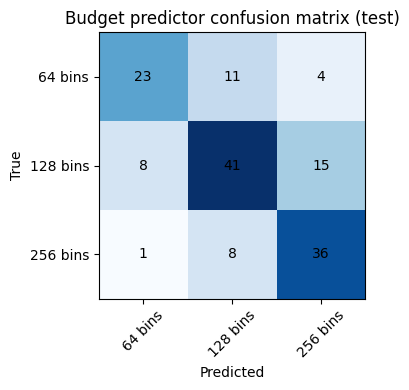

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_acc, test_preds, test_gts = evaluate(model, test_loader)
print("held-out test accuracy:", round(test_acc, 2))

target_names = [f"{CLASS_TO_BINS[i]} bins" for i in range(3)]
report = classification_report(test_gts, test_preds, target_names=target_names,
                               digits=3, output_dict=True, zero_division=0)
print(classification_report(test_gts, test_preds, target_names=target_names,
                            digits=3, zero_division=0))

cm = confusion_matrix(test_gts, test_preds)
RESULTS["final_test_accuracy"] = test_acc
RESULTS["classification_report_test"] = report
RESULTS["confusion_matrix_test"] = cm.tolist()


fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), target_names, rotation=45)
ax.set_yticks(range(3), target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_title("Budget predictor confusion matrix (test)")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### confidence-aware policy + threshold sweep

In [ ]:
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    probs, order = [], []
    for imgs, _, idxs in loader:
        p = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        probs.append(p); order += idxs.tolist()
    return np.concatenate(probs, 0), order

test_probs, test_order = get_probs(model, test_loader)
depth_cache = [np.array(Image.open(test_depth_p[i])) for i in test_order]

# fixed baselines, computed once
fixed_mse = {}
for b in [64, 128, 256]:
    fixed_mse[b] = float(np.mean([mse(d, quantize_depth(d, b)) for d in depth_cache]))
print("fixed baselines:", {k: round(v, 4) for k, v in fixed_mse.items()})
RESULTS["fixed_baselines"] = fixed_mse

def apply_policy(probs, tau_high, tau_low=0.70):
    chosen = []
    for p in probs:
        if p[2] > tau_high:
            chosen.append(256)
        elif p[0] > tau_low:
            chosen.append(64)
        else:
            chosen.append(128)
    return chosen

def eval_policy(chosen):
    errs = [mse(d, quantize_depth(d, b)) for d, b in zip(depth_cache, chosen)]
    return float(np.mean(chosen)), float(np.mean(errs))

tau_table = []
for tau in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]:
    chosen = apply_policy(test_probs, tau)
    avg_bins, avg_mse = eval_policy(chosen)
    dist = dict(Counter(chosen))
    tau_table.append({"tau": tau, "avg_bins": avg_bins, "mse": avg_mse, "dist": dist})
    print(f"tau={tau:.2f}  avg_bins={avg_bins:7.2f}  mse={avg_mse:.6f}  {dist}")

RESULTS["tau_sweep"] = tau_table


fixed baselines: {64: 1.311, 128: 0.4627, 256: 0.2018}
tau=0.50  avg_bins= 162.83  mse=0.300977  {64: 26, 128: 68, 256: 53}
tau=0.55  avg_bins= 161.96  mse=0.301242  {64: 26, 128: 69, 256: 52}
tau=0.60  avg_bins= 161.96  mse=0.301242  {64: 26, 128: 69, 256: 52}
tau=0.65  avg_bins= 161.96  mse=0.301242  {64: 26, 128: 69, 256: 52}
tau=0.70  avg_bins= 158.48  mse=0.314321  {64: 26, 128: 73, 256: 48}
tau=0.75  avg_bins= 157.61  mse=0.314364  {64: 26, 128: 74, 256: 47}
tau=0.80  avg_bins= 155.86  mse=0.314830  {64: 26, 128: 76, 256: 45}
tau=0.85  avg_bins= 153.25  mse=0.317210  {64: 26, 128: 79, 256: 42}


 #### oracle upper bound + normalized error

In [ ]:
# ---------------------------------------------------------------------------
# CELL 12b — oracle upper bound (adaptive binning)
# ---------------------------------------------------------------------------
test_y_ordered = [test_y[i] for i in test_order]
oracle_choice = [CLASS_TO_BINS[l] for l in test_y_ordered]
o_bins, o_mse = eval_policy(oracle_choice)
print(f"ORACLE: bins={o_bins:.2f}  mse={o_mse:.6f}")
RESULTS["oracle_policy"] = {"avg_bins": o_bins, "mse": o_mse}

ORACLE: bins=150.64  mse=0.265008


####  per-image comparison against matched fixed budget

In [ ]:
def fixed_curve_mse(b):
    """Predicted MSE for a uniform fixed budget of b bins (1/b^2 fit)."""
    return fixed_mse[256] * (256.0 / b) ** 2

def compare_policy(chosen, name):
    avg_b = float(np.mean(chosen))
    errs  = np.array([mse(d, quantize_depth(d, b)) for d, b in zip(depth_cache, chosen)])
    baseline_b = int(round(avg_b))
    base_errs = np.array([mse(d, quantize_depth(d, baseline_b)) for d in depth_cache])
    wins = float(np.mean(errs < base_errs)) * 100
    print(f"{name:18s} bins={avg_b:7.2f}  mse={errs.mean():.6f}  "
          f"matched-fixed={base_errs.mean():.6f}  "
          f"reduction={100*(1-errs.mean()/base_errs.mean()):+.1f}%  "
          f"win-rate={wins:.1f}%")
    return {"avg_bins": avg_b, "mse": float(errs.mean()),
            "matched_fixed_mse": float(base_errs.mean()), "win_rate": wins}

print("policy vs a fixed budget spending the SAME average bins:\n")
cmp_results = {}
cmp_results["oracle"] = compare_policy(oracle_choice, "oracle")
for tau in [0.50, 0.65, 0.80]:
    cmp_results[f"adaptive@{tau}"] = compare_policy(apply_policy(test_probs, tau),
                                                    f"adaptive@{tau}")
RESULTS["matched_budget_comparison"] = cmp_results

policy vs a fixed budget spending the SAME average bins:

oracle             bins= 150.64  mse=0.265008  matched-fixed=0.360585  reduction=+26.5%  win-rate=32.0%
adaptive@0.5       bins= 162.83  mse=0.300977  matched-fixed=0.335937  reduction=+10.4%  win-rate=36.7%
adaptive@0.65      bins= 161.96  mse=0.301242  matched-fixed=0.338244  reduction=+10.9%  win-rate=36.7%
adaptive@0.8       bins= 155.86  mse=0.314830  matched-fixed=0.354797  reduction=+11.3%  win-rate=32.0%


In [ ]:
# ---------------------------------------------------------------------------
# CELL 12d — effective bins + monotonicity + median comparison
# ---------------------------------------------------------------------------
def effective_bins(depth, bins):
    """Count distinct reconstruction levels actually produced by the quantizer."""
    return int(np.unique(quantize_adaptive(depth, bins)).size)

print("nominal -> effective bins (median over test set):")
for b in [32, 64, 128, 256]:
    eff = [effective_bins(d, b) for d in depth_cache]
    print(f"  {b:4d} -> median {np.median(eff):6.1f}   min {np.min(eff):4d}  max {np.max(eff):4d}")

print("\nfixed-budget curve, is it monotonic?")
prev = None
for b in range(120, 170, 5):
    m = float(np.mean([mse(d, quantize_depth(d, b)) for d in depth_cache]))
    flag = "  <-- NON-MONOTONIC" if prev is not None and m > prev else ""
    print(f"  {b:4d} bins  mse={m:.6f}{flag}")
    prev = m

# print("\nmean vs median (tail sensitivity):")
# for name, ch in [("oracle", oracle_choice),
#                  ("adaptive@0.5", apply_policy(test_probs, 0.50)),
#                  ("fixed150", [150]*len(depth_cache))]:
#     errs = np.array([mse(d, quantize_depth(d, b)) for d, b in zip(depth_cache, ch)])
#     print(f"  {name:14s} mean={errs.mean():.6f}  median={np.median(errs):.6f}  "
#           f"p90={np.percentile(errs,90):.6f}")

nominal -> effective bins (median over test set):
    32 -> median   32.0   min   32  max   32
    64 -> median   64.0   min   64  max   64
   128 -> median  128.0   min  128  max  128
   256 -> median  256.0   min  256  max  256

fixed-budget curve, is it monotonic?
   120 bins  mse=0.522085
   125 bins  mse=0.485761
   130 bins  mse=0.447621
   135 bins  mse=0.420926
   140 bins  mse=0.392392
   145 bins  mse=0.374947
   150 bins  mse=0.364328
   155 bins  mse=0.355583
   160 bins  mse=0.342647
   165 bins  mse=0.330906


In [ ]:
for b in [64, 128, 256]:
    m = float(np.mean([mse(d, quantize_depth(d, b)) for d in depth_cache]))
    print(f"{b:4d}  recomputed={m:.6f}   stored={fixed_mse[b]:.6f}")

  64  recomputed=1.310977   stored=1.310977
 128  recomputed=0.462704   stored=0.462704
 256  recomputed=0.201771   stored=0.201771


### plain argmax baseline

In [ ]:
argmax_choice = [CLASS_TO_BINS[int(np.argmax(p))] for p in test_probs]
am_bins, am_mse = eval_policy(argmax_choice)

# matched-fixed comparison, same as 12c
am_base = float(np.mean([mse(d, quantize_depth(d, int(round(am_bins))))
                         for d in depth_cache]))
am_wins = float(np.mean([mse(d, quantize_depth(d, b)) < mse(d, quantize_depth(d, int(round(am_bins))))
                         for d, b in zip(depth_cache, argmax_choice)])) * 100

print(f"argmax (no gating): bins={am_bins:.2f}  mse={am_mse:.6f}  "
      f"matched-fixed={am_base:.6f}  reduction={100*(1-am_mse/am_base):+.1f}%  "
      f"win-rate={am_wins:.1f}%")
print(f"argmax class dist: {dict(Counter(argmax_choice))}")

RESULTS["argmax_policy"] = {"avg_bins": am_bins, "mse": am_mse,
                            "matched_fixed_mse": am_base, "win_rate": am_wins}

argmax (no gating): bins=161.96  mse=0.299342  matched-fixed=0.338244  reduction=+11.5%  win-rate=38.8%
argmax class dist: {64: 32, 128: 60, 256: 55}


### timing benchmark (adaptive quantizer, real depth map)

In [ ]:
CHOSEN_TAU = 0.65
CHOSEN_TAU_LOW = 0.70


# time on a REAL depth map, not synthetic noise — uint8 ties and the
# percentile path are what the adaptive quantizer actually pays for
bench_depth = depth_cache[0]


RUNS = 300
timing = {}
for b in [64, 128, 256, 512]:
    for _ in range(30):
        quantize_adaptive(bench_depth, b)
    times = []
    for _ in range(RUNS):
        t0 = time.perf_counter(); quantize_adaptive(bench_depth, b)
        times.append((time.perf_counter() - t0) * 1000)
    timing[b] = {"mean_ms": float(np.median(times)),
                 "std_ms": float(np.std(times)),
                 "p25": float(np.percentile(times, 25)),
                 "p75": float(np.percentile(times, 75))}
    print(f"{b:4d} bins | median {np.median(times):7.3f}  IQR "
          f"[{np.percentile(times,25):.2f}, {np.percentile(times,75):.2f}] ms")

RESULTS["timing_benchmark"] = timing

# interpolate cost for arbitrary bin counts (the policy uses 64/128/256 only,
# but the matched-fixed baseline sits at a non-candidate value like 162)
def interp_ms(b):
    xs = np.array([64, 128, 256, 512], dtype=float)
    ys = np.array([timing[int(x)]["mean_ms"] for x in xs])
    return float(np.interp(b, xs, ys))

chosen = apply_policy(test_probs, CHOSEN_TAU, tau_low=CHOSEN_TAU_LOW)
avg_bins_chosen = float(np.mean(chosen))

adaptive_ms = float(np.mean([timing[b]["mean_ms"] for b in chosen]))
fixed256_ms = timing[256]["mean_ms"]
matched_ms  = interp_ms(avg_bins_chosen)

print(f"\npolicy @tau={CHOSEN_TAU} -> avg {avg_bins_chosen:.2f} bins")
print(f"  adaptive expected time : {adaptive_ms:7.3f} ms")
print(f"  fixed-256 baseline     : {fixed256_ms:7.3f} ms   "
      f"-> saving {100*(1-adaptive_ms/fixed256_ms):+.1f}%")
print(f"  matched-cost fixed     : {matched_ms:7.3f} ms   "
      f"-> saving {100*(1-adaptive_ms/matched_ms):+.1f}%  (should be ~0)")

RESULTS["expected_runtime"] = {
    "tau": CHOSEN_TAU, "avg_bins": avg_bins_chosen,
    "adaptive_ms": adaptive_ms, "fixed256_ms": fixed256_ms,
    "matched_fixed_ms": matched_ms,
    "saving_vs_fixed256_pct": 100 * (1 - adaptive_ms / fixed256_ms),
}


  64 bins | median  22.419  IQR [22.00, 22.89] ms
 128 bins | median  26.374  IQR [25.77, 34.49] ms
 256 bins | median  30.371  IQR [29.41, 39.00] ms
 512 bins | median  34.662  IQR [33.39, 43.50] ms

policy @tau=0.65 -> avg 161.96 bins
  adaptive expected time :  27.089 ms
  fixed-256 baseline     :  30.371 ms   -> saving +10.8%
  matched-cost fixed     :  27.435 ms   -> saving +1.3%  (should be ~0)


### Figure 1: tradeoff, WITH the matched-fixed reference curve

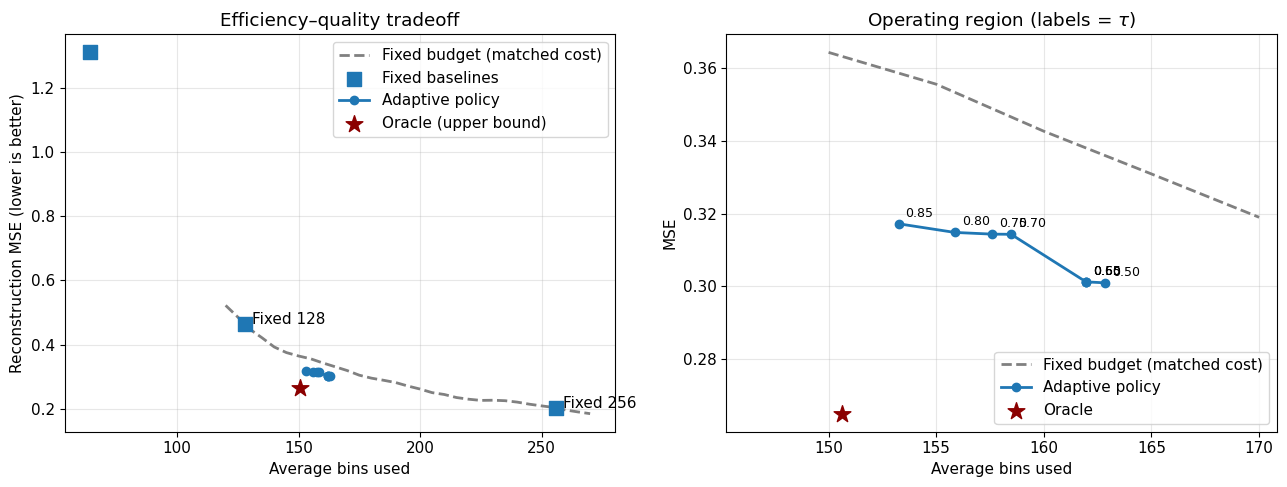

In [ ]:
plt.rcParams.update({"font.size": 11})

# adaptive policy across tau
ad = sorted([(r["avg_bins"], r["mse"], r["tau"]) for r in tau_table])
ad_bins = [x[0] for x in ad]
ad_mse  = [x[1] for x in ad]
ad_tau  = [x[2] for x in ad]

# the fixed-budget curve, computed empirically over the same range.
# THIS is the honest baseline: what you'd get spending the same bins uniformly.
curve_bins = list(range(120, 275, 5))
curve_mse = [float(np.mean([mse(d, quantize_depth(d, b)) for d in depth_cache]))
             for b in curve_bins]

# oracle point
o_bins, o_mse = eval_policy(oracle_choice)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT: full view ----
ax = axes[0]
ax.plot(curve_bins, curve_mse, lw=2, ls="--", color="grey",
        label="Fixed budget (matched cost)")
ax.scatter([64, 128, 256],
           [fixed_mse[64], fixed_mse[128], fixed_mse[256]],
           s=110, marker="s", zorder=3, label="Fixed baselines")
ax.plot(ad_bins, ad_mse, marker="o", lw=2, label="Adaptive policy")
ax.scatter([o_bins], [o_mse], s=160, marker="*", color="darkred",
           zorder=4, label="Oracle (upper bound)")
for b, m, lab in [(128, fixed_mse[128], "Fixed 128"), (256, fixed_mse[256], "Fixed 256")]:
    ax.annotate(lab, (b + 3, m))
ax.set_title("Efficiency–quality tradeoff")
ax.set_xlabel("Average bins used")
ax.set_ylabel("Reconstruction MSE (lower is better)")
ax.grid(alpha=0.3); ax.legend()

# ---- RIGHT: zoom on the operating region ----
ax2 = axes[1]
lo, hi = min(ad_bins) - 8, max(ad_bins) + 8
mask = [(b >= lo and b <= hi) for b in curve_bins]
ax2.plot([b for b, m in zip(curve_bins, mask) if m],
         [c for c, m in zip(curve_mse, mask) if m],
         lw=2, ls="--", color="grey", label="Fixed budget (matched cost)")
ax2.plot(ad_bins, ad_mse, marker="o", lw=2, label="Adaptive policy")
ax2.scatter([o_bins], [o_mse], s=160, marker="*", color="darkred",
            zorder=4, label="Oracle")
for b, m, t in zip(ad_bins, ad_mse, ad_tau):
    ax2.annotate(f"{t:.2f}", (b, m), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.set_xlim(lo, hi)
ax2.set_title(r"Operating region (labels = $\tau$)")
ax2.set_xlabel("Average bins used"); ax2.set_ylabel("MSE")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig1_tradeoff.png", dpi=400, bbox_inches="tight")
plt.savefig(f"{OUTDIR}/fig1_tradeoff.pdf", bbox_inches="tight")
plt.show()

RESULTS["fixed_curve"] = {"bins": curve_bins, "mse": curve_mse}


### Figure 2: qualitative comparison (TEST set)

matched-cost fixed budget for this policy: 162 bins
selected rows (test_idx, bins, kind): [(86, 64, 'best case'), (79, 64, 'median case'), (137, 128, 'best case'), (113, 128, 'median case'), (93, 256, 'best case'), (110, 256, 'median case')]


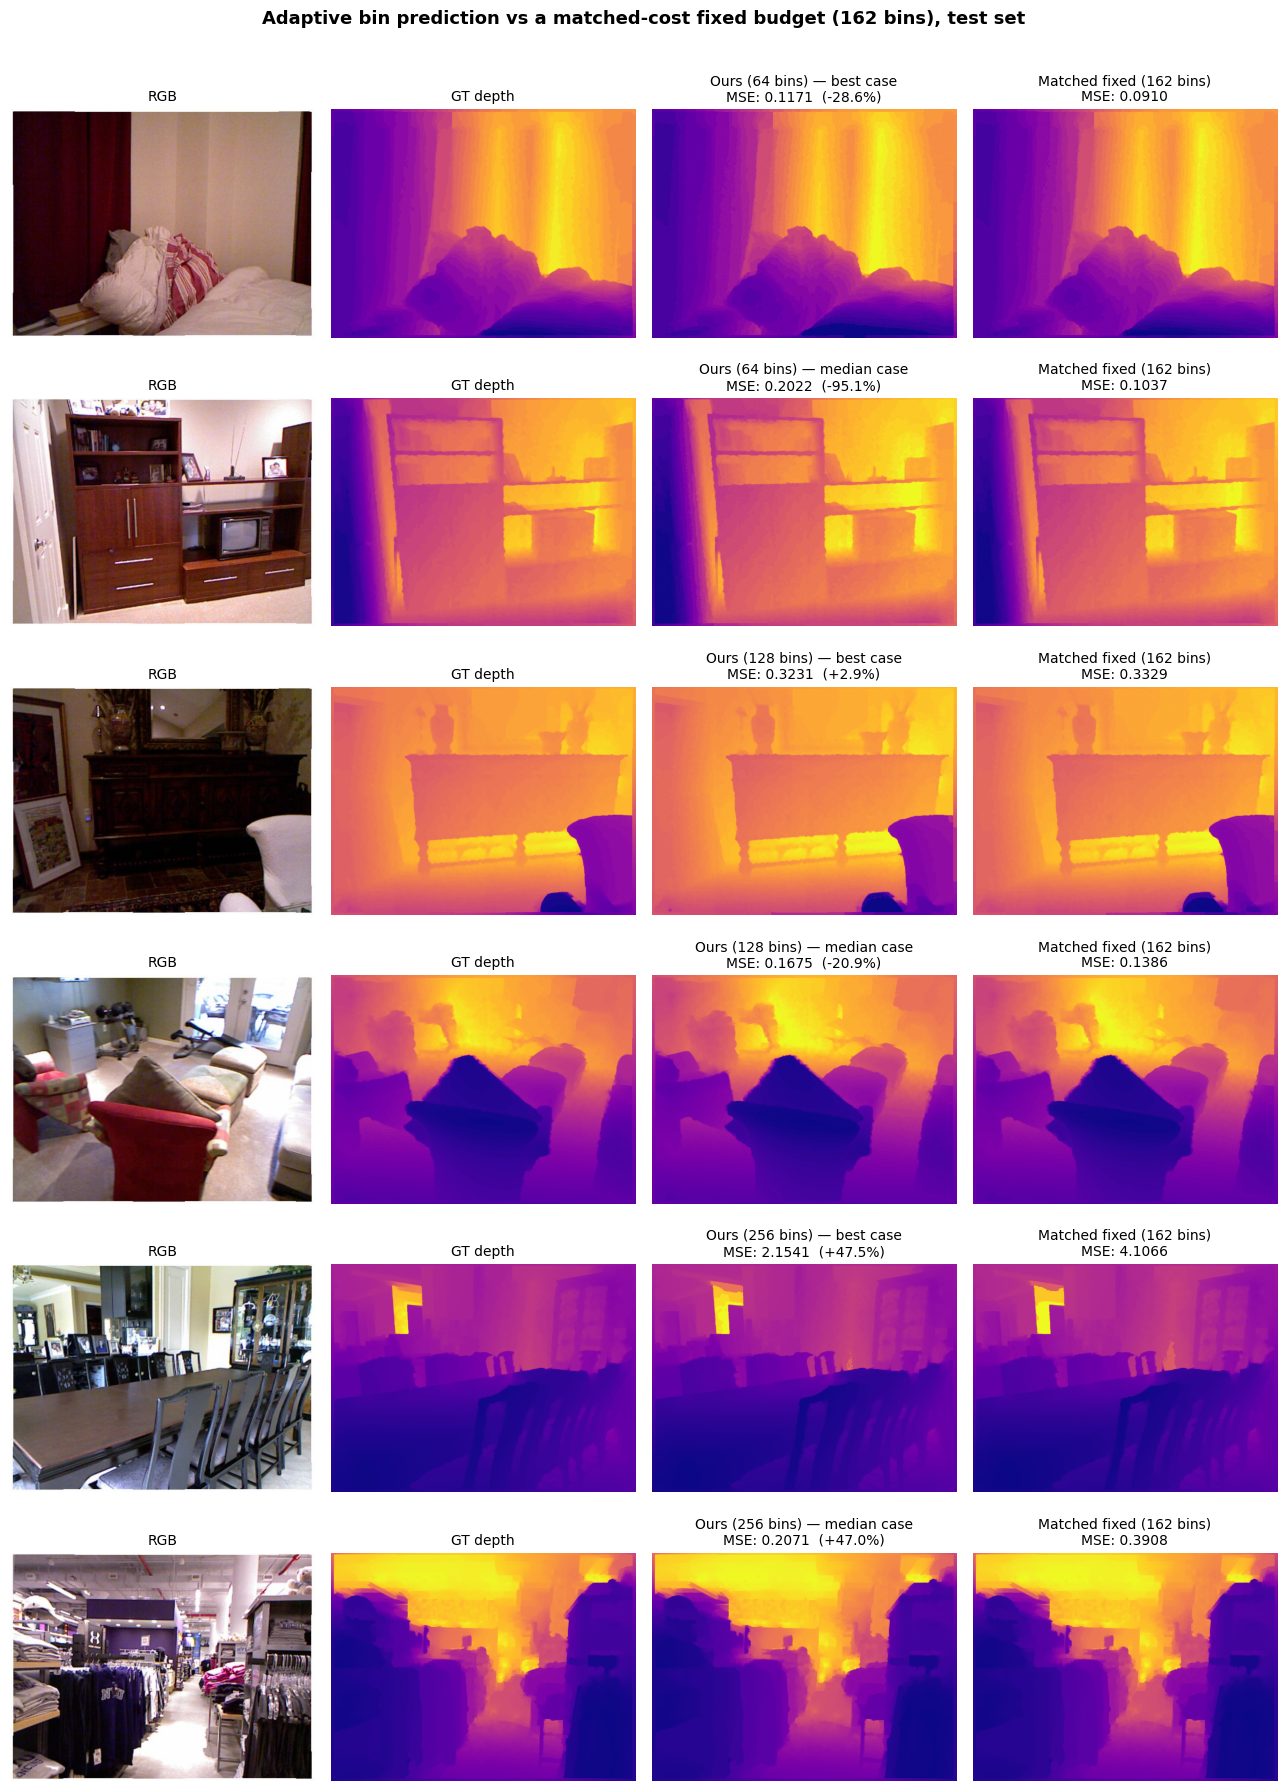

In [ ]:
# ---------------------------------------------------------------------------
# CELL 16 (corrected) — qualitative figure vs the MATCHED-COST fixed budget
#
# The previous version compared each adaptive reconstruction against fixed-256.
# That is the comparison Section 5.2 explicitly argues is not the right one:
# a policy spending ~162 bins on average should be judged against a fixed
# budget of ~162 bins. Comparing 64 bins to 256 bins loses by construction,
# which is why every row of the old figure showed a negative delta.
# ---------------------------------------------------------------------------
chosen_all = apply_policy(test_probs, CHOSEN_TAU, tau_low=CHOSEN_TAU_LOW)
MATCHED = int(round(float(np.mean(chosen_all))))      # 162 at tau = 0.65
print(f"matched-cost fixed budget for this policy: {MATCHED} bins")

# For each budget, pick a favourable case and a typical (median) case,
# ranked by how the policy does against the MATCHED fixed budget.
rows = []
for target in [64, 128, 256]:
    cands = [(pos, ti) for pos, (ti, b) in enumerate(zip(test_order, chosen_all))
             if b == target]
    if not cands:
        print(f"  no test image assigned {target} bins")
        continue

    scored = []
    for pos, ti in cands:
        d = np.array(Image.open(test_depth_p[ti]))
        ours    = mse(d, quantize_depth(d, target))
        matched = mse(d, quantize_depth(d, MATCHED))
        scored.append((ours - matched, ti, target))   # negative = we win
    scored.sort(key=lambda x: x[0])

    rows.append((scored[0][1], scored[0][2], "best case"))
    if len(scored) > 2:
        mid = scored[len(scored) // 2]
        rows.append((mid[1], mid[2], "median case"))

print("selected rows (test_idx, bins, kind):", rows)
N_SHOW = len(rows)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(13, 3.0 * N_SHOW))
if N_SHOW == 1:
    axes = axes.reshape(1, -1)

for row, (ti, bins_pred, kind) in enumerate(rows):
    img   = Image.open(test_rgb[ti]).convert("RGB")
    depth = np.array(Image.open(test_depth_p[ti]))

    ours    = quantize_depth(depth, bins_pred)
    matched = quantize_depth(depth, MATCHED)
    ours_e, matched_e = mse(depth, ours), mse(depth, matched)
    delta = 100 * (1 - ours_e / matched_e)            # positive = we win

    panels = [
        (img,     "RGB", None),
        (depth,   "GT depth", "plasma"),
        (ours,    f"Ours ({bins_pred} bins) — {kind}\nMSE: {ours_e:.4f}  ({delta:+.1f}%)", "plasma"),
        (matched, f"Matched fixed ({MATCHED} bins)\nMSE: {matched_e:.4f}", "plasma"),
    ]
    for col, (im, title, cmap) in enumerate(panels):
        axes[row, col].imshow(im, cmap=cmap)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")

plt.suptitle(f"Adaptive bin prediction vs a matched-cost fixed budget "
             f"({MATCHED} bins), test set",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig2_qualitative.png", dpi=400, bbox_inches="tight")
plt.savefig(f"{OUTDIR}/fig2_qualitative.pdf", bbox_inches="tight")
plt.show()

RESULTS["qualitative_rows"] = [
    {"test_idx": int(ti), "bins": int(b), "kind": k} for ti, b, k in rows
]

### dump everything + print the numbers that go in the paper

In [ ]:
with open(f"{OUTDIR}/results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=float)

print("saved ->", f"{OUTDIR}/results.json\n")
print("=" * 62)
print("NUMBERS FOR THE PAPER")
print("=" * 62)

print(f"\ndataset:  {RESULTS['final_dataset_size']} images, lambda = {RESULTS['chosen_lambda']}")
print(f"  class counts: {RESULTS['final_class_counts']}")
print(f"  split: {RESULTS['split']}")

maj = max(Counter(test_y).values()) / len(test_y) * 100
print(f"\nclassification (held-out test):")
for k, v in RESULTS["architecture_ablation"].items():
    print(f"  {k:22s} val {v['best_val']:5.2f}%   test {v['test_acc']:5.2f}%")
print(f"  majority-class baseline: {maj:.2f}%")

print(f"\npolicy vs matched-cost fixed budget:")
for k, v in RESULTS["matched_budget_comparison"].items():
    red = 100 * (1 - v["mse"] / v["matched_fixed_mse"])
    print(f"  {k:16s} bins {v['avg_bins']:7.2f}  mse {v['mse']:.6f}  "
          f"reduction {red:+5.1f}%  win-rate {v['win_rate']:.1f}%")

r = RESULTS["expected_runtime"]
print(f"\nruntime @tau={r['tau']}:  {r['adaptive_ms']:.3f} ms vs "
      f"{r['fixed256_ms']:.3f} ms fixed-256  "
      f"({r['saving_vs_fixed256_pct']:+.1f}%)")
print("=" * 62)

saved -> results/results.json

NUMBERS FOR THE PAPER

dataset:  978 images, lambda = 0.5
  class counts: {'64': 255, '128': 422, '256': 301}
  split: {'train': 684, 'val': 147, 'test': 147}

classification (held-out test):
  tiny_cnn               val 57.82%   test 48.30%
  resnet18_full_ft       val 72.11%   test 68.03%
  resnet18_frozen        val 59.18%   test 57.82%
  majority-class baseline: 43.54%

policy vs matched-cost fixed budget:
  oracle           bins  150.64  mse 0.265008  reduction +26.5%  win-rate 32.0%
  adaptive@0.5     bins  162.83  mse 0.300977  reduction +10.4%  win-rate 36.7%
  adaptive@0.65    bins  161.96  mse 0.301242  reduction +10.9%  win-rate 36.7%
  adaptive@0.8     bins  155.86  mse 0.314830  reduction +11.3%  win-rate 32.0%

runtime @tau=0.65:  27.089 ms vs 30.371 ms fixed-256  (+10.8%)


In [ ]:
# ---------------------------------------------------------------------------
# CELL 18 — save everything to Google Drive
# ---------------------------------------------------------------------------
import shutil
from datetime import datetime

# mount if not already
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")

STAMP = datetime.now().strftime("%Y%m%d_%H%M")
DRIVE_DIR = f"/content/drive/MyDrive/bin_budget_prediction/run_{STAMP}"
os.makedirs(DRIVE_DIR, exist_ok=True)

# 1. results folder (figures + json)
for f in os.listdir(OUTDIR):
    shutil.copy2(os.path.join(OUTDIR, f), os.path.join(DRIVE_DIR, f))

# 2. trained model weights
if os.path.exists("budget_predictor.pth"):
    shutil.copy2("budget_predictor.pth", os.path.join(DRIVE_DIR, "budget_predictor.pth"))

# 3. the exact file lists + labels, so the split is reproducible without rerunning
split_record = {
    "seed": SEED,
    "lambda": LAMBDA,
    "chosen_tau": CHOSEN_TAU,
    "chosen_tau_low": CHOSEN_TAU_LOW,
    "train": {"rgb": train_rgb, "depth": train_depth_p, "y": [int(v) for v in train_y]},
    "val":   {"rgb": val_rgb,   "depth": val_depth_p,   "y": [int(v) for v in val_y]},
    "test":  {"rgb": test_rgb,  "depth": test_depth_p,  "y": [int(v) for v in test_y]},
}
with open(os.path.join(DRIVE_DIR, "split_record.json"), "w") as f:
    json.dump(split_record, f, indent=2)

# 4. the error cache — this is the expensive one to recompute
np.save(os.path.join(DRIVE_DIR, "error_cache.npy"), error_cache)
with open(os.path.join(DRIVE_DIR, "subset_paths.json"), "w") as f:
    json.dump({"rgb": subset_rgb, "depth": subset_depth}, f, indent=2)

print("saved to:", DRIVE_DIR)
for f in sorted(os.listdir(DRIVE_DIR)):
    size = os.path.getsize(os.path.join(DRIVE_DIR, f)) / 1024
    print(f"  {f:28s} {size:8.1f} KB")

saved to: /content/drive/MyDrive/bin_budget_prediction/run_20260828_0551
  budget_predictor.pth          43742.8 KB
  confusion_matrix.png             78.4 KB
  error_cache.npy                  31.4 KB
  fig1_tradeoff.pdf                22.3 KB
  fig1_tradeoff.png               378.9 KB
  fig2_qualitative.pdf           1656.1 KB
  fig2_qualitative.png          18734.6 KB
  results.json                     18.6 KB
  split_record.json               142.4 KB
  subset_paths.json               132.6 KB


In [ ]:
for v in ["test_probs","test_order","test_rgb","test_depth_p",
          "CHOSEN_TAU","CHOSEN_TAU_LOW","apply_policy","quantize_depth","OUTDIR"]:
    print(f"{v:18s} {'OK' if v in dir() else 'MISSING'}")

test_probs         OK
test_order         OK
test_rgb           OK
test_depth_p       OK
CHOSEN_TAU         OK
CHOSEN_TAU_LOW     OK
apply_policy       OK
quantize_depth     OK
OUTDIR             OK
